# LECTURA PICKLE


In [59]:
ruta_leer_pickle = r'C:\Users\migue\Desktop\Cositis\unistuff\TFG\mio\data\pickles\VGG19Morton\final.pkl'

              precision    recall  f1-score
browsing       0.704322  0.618730  0.658758
voice          0.587997  0.629540  0.608060
streaming      0.740129  0.756905  0.748423
filetransfer   0.855304  0.879429  0.867198
accuracy       0.721151  0.721151  0.721151
macro avg      0.721938  0.721151  0.720610
weighted avg   0.721938  0.721151  0.720610


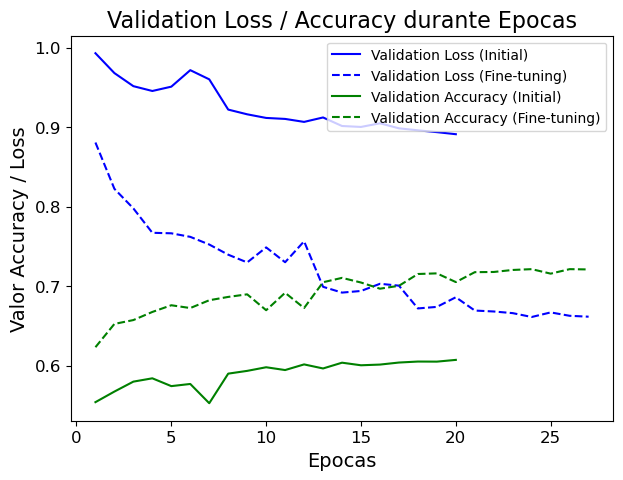

              precision  recall  f1-score accuracy
browsing           0.70    0.62      0.66         
voice              0.59    0.63      0.61         
streaming          0.74    0.76      0.75         
filetransfer       0.86    0.88      0.87         
Average            0.72    0.72      0.72     0.72


In [60]:
#Loading de los pickles
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

label_map = {
    0: 'browsing',
    1: 'voice',
    2: 'streaming',
    3: 'filetransfer'
}

with open(ruta_leer_pickle, 'rb') as f:
    resultados = pickle.load(f)

# Acceder a las métricas iniciales
historial_inicial = resultados['historial_inicial']
historial_finetune = resultados['historial_finetune']

# Acceder al reporte inicial y mostrarlo en una tabla
reporte_finetune_df = pd.DataFrame(resultados['reporte_finetune']).transpose()
print(reporte_finetune_df[['precision', 'recall', 'f1-score']])

# Acceder a los datos del historial desde el pickle cargado
val_loss_inicial = historial_inicial['val_loss']
val_acc_inicial = historial_inicial['val_accuracy']

val_loss_ft = historial_finetune['val_loss']
val_acc_ft = historial_finetune['val_accuracy']

# Número total de epochs para concatenar ambas fases
epochs_inicial = range(1, len(val_loss_inicial) + 1)
epochs_ft = range(1, len(val_loss_ft) + 1)

plt.figure(figsize=(7, 5))

# Gráfica para LOSS
plt.plot(epochs_inicial, val_loss_inicial, 'b-', label='Validation Loss (Initial)')
plt.plot(epochs_ft, val_loss_ft, 'b--', label='Validation Loss (Fine-tuning)')

# Gráfica para ACCURACY
plt.plot(epochs_inicial, val_acc_inicial, 'g-', label='Validation Accuracy (Initial)')
plt.plot(epochs_ft, val_acc_ft, 'g--', label='Validation Accuracy (Fine-tuning)')

# Etiquetas y título con fontsize
plt.xlabel('Epocas', fontsize=14)
plt.ylabel('Valor Accuracy / Loss', fontsize=14)
plt.title('Validation Loss / Accuracy durante Epocas', fontsize=16)

# Cambiar fontsize de los números de los ejes
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(False)
plt.legend()
plt.show()

# Reformatear y mostrar el reporte en el formato deseado
df_fmt = reporte_finetune_df[['precision', 'recall', 'f1-score']].round(2)

# Extraer las clases y los promedios
clases = ['browsing', 'voice', 'streaming', 'filetransfer']
df_clases = df_fmt.loc[clases]
df_clases['accuracy'] = ''  # Añadir columna vacía

# Extraer valores promedio y accuracy
macro_avg = df_fmt.loc['macro avg']
accuracy_val = reporte_finetune_df.loc['accuracy', 'precision']
average_row = pd.Series({
    'precision': round(macro_avg['precision'], 2),
    'recall': round(macro_avg['recall'], 2),
    'f1-score': round(macro_avg['f1-score'], 2),
    'accuracy': round(accuracy_val, 2)
}, name='Average')

# Concatenar todo
df_final = pd.concat([df_clases, pd.DataFrame([average_row])])

# Mostrar tabla final
print(df_final)


# LOADING PICKLE SIN FINE-TUNE

              precision    recall  f1-score
browsing       0.653444  0.316651  0.426584
voice          0.482379  0.577063  0.525490
streaming      0.466881  0.592968  0.522424
filetransfer   0.800926  0.840222  0.820104
accuracy       0.581726  0.581726  0.581726
macro avg      0.600908  0.581726  0.573651
weighted avg   0.600908  0.581726  0.573651


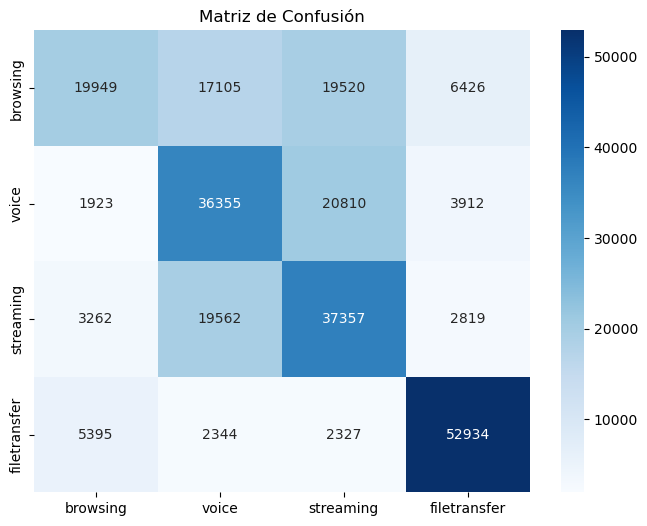

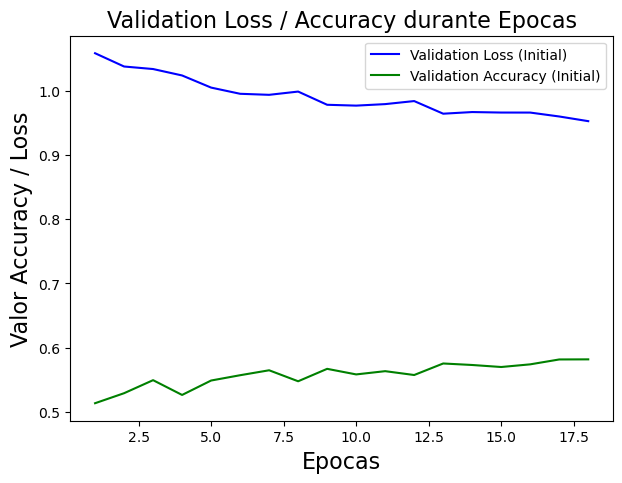

In [39]:
#Loading de los pickles
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

label_map = {
    0: 'browsing',
    1: 'voice',
    2: 'streaming',
    3: 'filetransfer'
}

with open(ruta_leer_pickle, 'rb') as f:
    resultados = pickle.load(f)

# Acceder a las métricas iniciales
historial_inicial = resultados['historial_inicial']


# Acceder al reporte inicial y mostrarlo en una tabla
reporte_inicial_df = pd.DataFrame(resultados['reporte_inicial']).transpose()
print(reporte_inicial_df[['precision', 'recall', 'f1-score']])

# Acceder a las matrices de confusión y visualizarlas
plt.figure(figsize=(8, 6))
sns.heatmap(resultados['conf_matrix_inicial'], annot=True, cmap='Blues', fmt='d', 
            xticklabels=label_map.values(), yticklabels=label_map.values())
plt.title('Matriz de Confusión')
plt.show()


# Acceder a los datos del historial desde el pickle cargado
val_loss_inicial = historial_inicial['val_loss']
val_acc_inicial = historial_inicial['val_accuracy']

# Número total de epochs para concatenar ambas fases
epochs_inicial = range(1, len(val_loss_inicial) + 1)

plt.figure(figsize=(7, 5))

# Gráfica para LOSS
plt.plot(epochs_inicial, val_loss_inicial, 'b-', label='Validation Loss (Initial)')

# Gráfica para ACCURACY (en el mismo gráfico pero con un eje diferente)
plt.plot(epochs_inicial, val_acc_inicial, 'g-', label='Validation Accuracy (Initial)')

# Etiquetas y título
plt.xlabel('Epocas', fontsize=16)
plt.ylabel('Valor Accuracy / Loss', fontsize=16)
plt.title('Validation Loss / Accuracy durante Epocas', fontsize=16)
plt.grid(False)
plt.legend()
plt.show()